**Import Libraries**

In [ ]:
import os
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import kagglehub

Step 1 — Mount Google Drive

We connect Colab with your Google Drive where your dataset is stored.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Set Dataset Path

In [ ]:
DATA_PATH = "/content/drive/MyDrive/data"
WINDOW_SIZE = 50

X = []
y = []
file_ids = []

In [ ]:
import os

print(os.listdir(DATA_PATH))

['ideal', 'high', 'low', 'mid']


Import Visualization Libraries

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

Load One Sample File for Visualization

In [ ]:
sample_file = "/content/drive/MyDrive/data/high/cooler_high_1.csv"

df_sample = pd.read_csv(
    sample_file,
    header=None,
    sep=None,
    engine="python",
    encoding="latin1"
)

df_sample.columns = ["x", "y", "z"]

df_sample = df_sample.apply(pd.to_numeric, errors='coerce')
df_sample = df_sample.dropna()

print(df_sample.head())

      x     y      z
1  0.75  0.24 -11.14
2  0.63  0.78 -10.36
3  0.12  0.75 -11.18
4  0.67  0.20 -11.10
5  0.63  0.47 -11.26


Raw Signal Plot (X, Y, Z Axes)

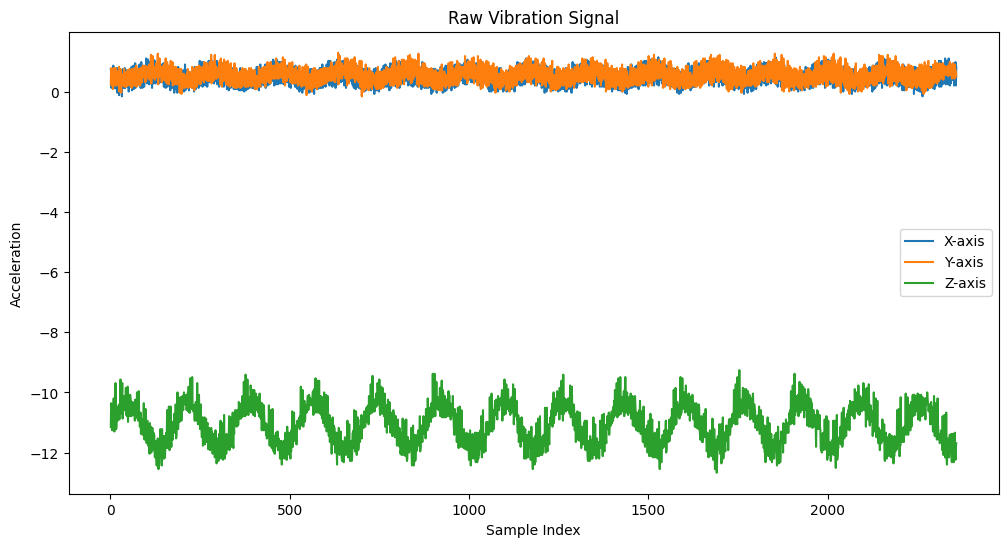

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df_sample["x"], label="X-axis")
plt.plot(df_sample["y"], label="Y-axis")
plt.plot(df_sample["z"], label="Z-axis")

plt.title("Raw Vibration Signal")
plt.xlabel("Sample Index")
plt.ylabel("Acceleration")
plt.legend()

plt.show()

Magnitude Calculation

In [ ]:
df_sample["mag"] = np.sqrt(
    df_sample["x"]**2 +
    df_sample["y"]**2 +
    df_sample["z"]**2
)

print(df_sample.head())

      x     y      z        mag
1  0.75  0.24 -11.14  11.167797
2  0.63  0.78 -10.36  10.408405
3  0.12  0.75 -11.18  11.205771
4  0.67  0.20 -11.10  11.122001
5  0.63  0.47 -11.26  11.287400


Histogram of Magnitude

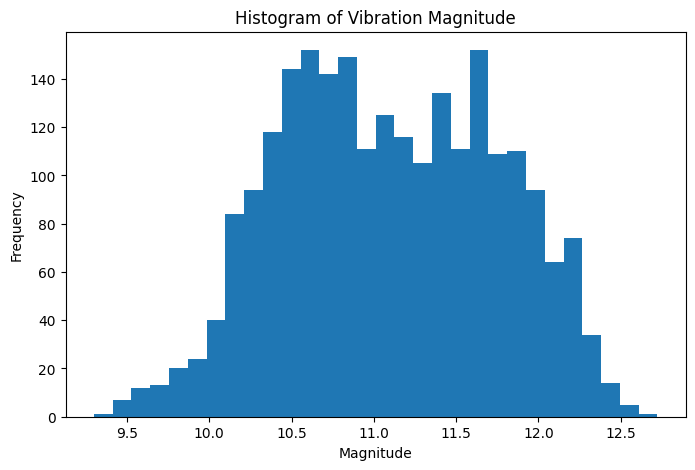

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df_sample["mag"], bins=30)

plt.title("Histogram of Vibration Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")

plt.show()

Frequency Distribution Curve

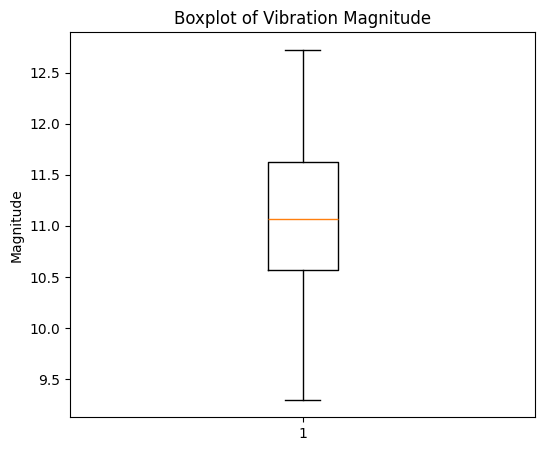

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot(df_sample["mag"])

plt.title("Boxplot of Vibration Magnitude")
plt.ylabel("Magnitude")

plt.show()

Boxplot (Outlier Detection)

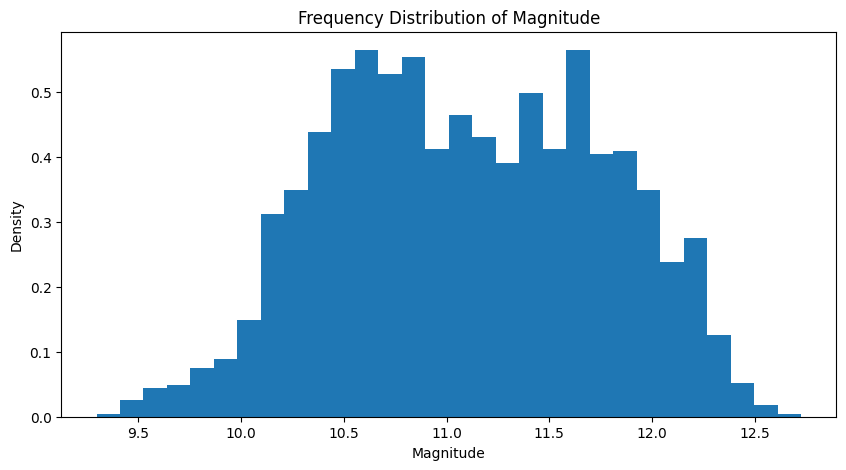

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    df_sample["mag"],
    bins=30,
    density=True
)

plt.title("Frequency Distribution of Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Density")

plt.show()

In [ ]:
for label in os.listdir(DATA_PATH):
    folder = os.path.join(DATA_PATH, label)

    if not os.path.isdir(folder):
        continue

    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)

        if not os.path.isfile(file_path) or not file.endswith(".csv"):
            continue

        try:
            # Read CSV
            df = pd.read_csv(
                file_path,
                header=None,
                sep=None,
                engine="python",
                encoding="latin1"
            )

            # Skip bad files
            if df.shape[1] != 3:
                print("Skipping bad file:", file_path)
                continue

            df.columns = ["x", "y", "z"]

            # Convert to numeric
            df = df.apply(pd.to_numeric, errors='coerce')
            df = df.dropna()

            if len(df) < WINDOW_SIZE:
                continue

            # Compute magnitude
            df["mag"] = np.sqrt(
                df["x"]**2 +
                df["y"]**2 +
                df["z"]**2
            )

            # Remove gravity effect
            df["mag"] = df["mag"] - df["mag"].mean()

            # Windowing
            for i in range(0, len(df) - WINDOW_SIZE, WINDOW_SIZE):
                window = df["mag"].iloc[i:i+WINDOW_SIZE]

                features = [
                    window.mean(),
                    window.std(),
                    window.max(),
                    window.min(),
                    np.sqrt(np.mean(window**2))  # RMS
                ]

                X.append(features)
                y.append(label)
                file_ids.append(file_path)

        except Exception as e:
            print("Error in file:", file_path)
            print(e)

Skipping bad file: /content/drive/MyDrive/data/ideal/ideal_4.csv


In [ ]:
for label in os.listdir(DATA_PATH):
    folder = os.path.join(DATA_PATH, label)

    if not os.path.isdir(folder):
        continue

    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)

        if not os.path.isfile(file_path) or not file.endswith(".csv"):
            continue

        try:
            # Read CSV
            df = pd.read_csv(
                file_path,
                header=None,
                sep=None,
                engine="python",
                encoding="latin1"
            )

            # Skip bad files
            if df.shape[1] != 3:
                print("Skipping bad file:", file_path)
                continue

            df.columns = ["x", "y", "z"]

            # Convert to numeric
            df = df.apply(pd.to_numeric, errors='coerce')
            df = df.dropna()

            if len(df) < WINDOW_SIZE:
                continue

            # Compute magnitude
            df["mag"] = np.sqrt(
                df["x"]**2 +
                df["y"]**2 +
                df["z"]**2
            )

            # Remove gravity effect
            df["mag"] = df["mag"] - df["mag"].mean()

            # Windowing
            for i in range(0, len(df) - WINDOW_SIZE, WINDOW_SIZE):
                window = df["mag"].iloc[i:i+WINDOW_SIZE]

                features = [
                    window.mean(),
                    window.std(),
                    window.max(),
                    window.min(),
                    np.sqrt(np.mean(window**2))  # RMS
                ]

                X.append(features)
                y.append(label)
                file_ids.append(file_path)

        except Exception as e:
            print("Error in file:", file_path)
            print(e)

Skipping bad file: /content/drive/MyDrive/data/ideal/ideal_4.csv


In [ ]:
X = np.array(X)
y = np.array(y)
file_ids = np.array(file_ids)

print("Total Samples:", len(X))

Total Samples: 2154


In [ ]:
gss = GroupShuffleSplit(
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=file_ids)
)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1676
Testing Samples: 478


Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Initialize Models

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

svm_model = SVC(
    kernel='rbf',
    random_state=42
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

print("Models initialized successfully.")


Models initialized successfully.


Train Models

In [ ]:
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

print("All 3 models trained successfully.")

All 3 models trained successfully.


Predictions

In [ ]:
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test)
knn_pred = knn_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


Metric Function

In [ ]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average='weighted'
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average='weighted'
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            average='weighted'
        )
    }

Comparative Table


In [ ]:
results = pd.DataFrame({
    "Random Forest": get_metrics(y_test, rf_pred),
    "SVM": get_metrics(y_test, svm_pred),
    "KNN": get_metrics(y_test, knn_pred)
}).T

results = results.round(4)

print("\nComparative Performance Table:\n")
print(results)


Comparative Performance Table:

               Accuracy  Precision  Recall  F1 Score
Random Forest    0.9163     0.9333  0.9163    0.9220
SVM              0.9372     0.9451  0.9372    0.9344
KNN              0.9205     0.9322  0.9205    0.9219


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


A perfect accuracy (1.0) with models like SVM and KNN can sometimes be an indicator of a few things:

1.  **Truly Separable Data**: The classes might be so well-defined by the extracted features that even simpler models can perfectly distinguish them.
2.  **Data Leakage**: Information from the test set might have inadvertently influenced the training process. While `GroupShuffleSplit` helps with this by keeping files intact within splits, sometimes leakage can occur in feature engineering if not handled carefully.
3.  **Small / Easy Test Set**: If the test set is small and happens to contain samples that are perfectly classified, a 1.0 accuracy can result.

Let's inspect the class distribution in both the training and testing sets to gain more insight.

In [ ]:
import pandas as pd

print("\nClass distribution in Training Set:")
print(pd.Series(y_train).value_counts())

print("\nClass distribution in Test Set:")
print(pd.Series(y_test).value_counts())


Class distribution in Training Set:
mid      570
ideal    434
low      396
high     276
Name: count, dtype: int64

Class distribution in Test Set:
high     210
ideal    158
low      110
Name: count, dtype: int64


Accuracy Comparison

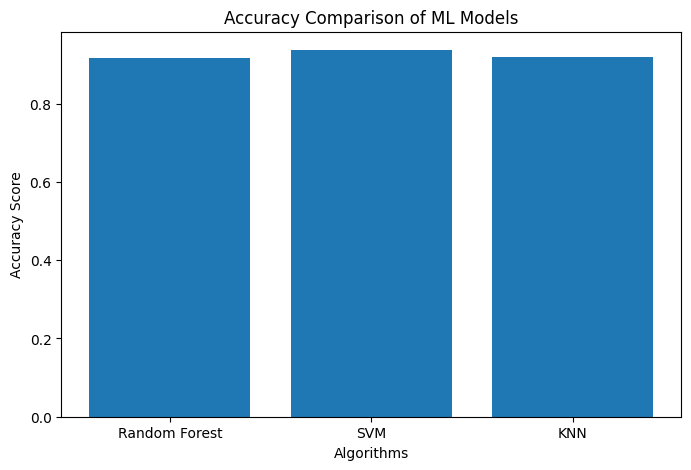

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results.index,
    results["Accuracy"]
)

plt.title("Accuracy Comparison of ML Models")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy Score")

plt.show()

Full Metrics Comparison

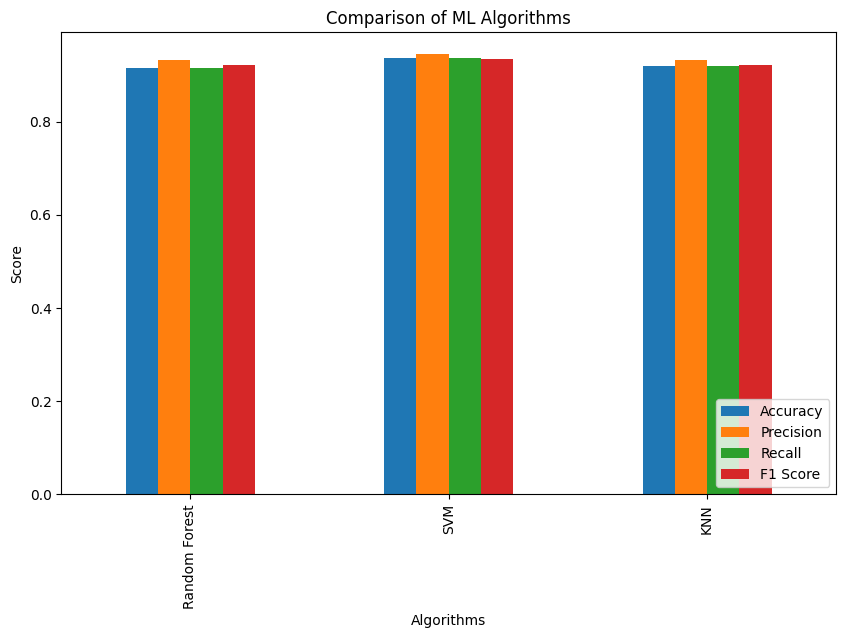

In [ ]:
results.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Comparison of ML Algorithms")
plt.xlabel("Algorithms")
plt.ylabel("Score")
plt.legend(loc='lower right')

plt.show()

Confusion Matrix for Random Forest

<Figure size 800x600 with 0 Axes>

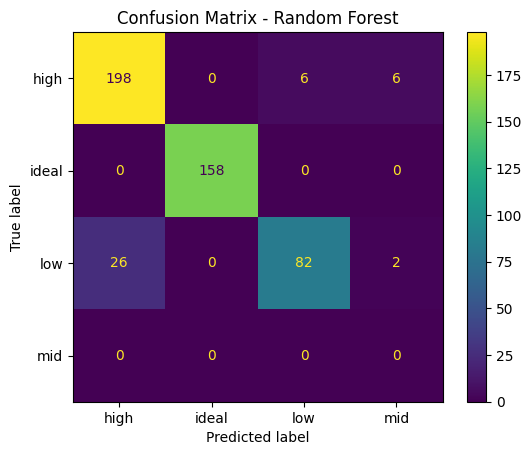

In [ ]:
all_classes = rf_model.classes_

cm = confusion_matrix(y_test, rf_pred, labels=all_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=all_classes
)

plt.figure(figsize=(8, 6))
disp.plot(values_format='d')

plt.title("Confusion Matrix - Random Forest")
plt.grid(False)

plt.show()

Classification Reports

In [ ]:
print("\n========== RANDOM FOREST ==========")
print(classification_report(y_test, rf_pred))

print("\n========== SVM ==========")
print(classification_report(y_test, svm_pred))

print("\n========== KNN ==========")
print(classification_report(y_test, knn_pred))


========== RANDOM FOREST ==========
              precision    recall  f1-score   support

        high       0.88      0.94      0.91       210
       ideal       1.00      1.00      1.00       158
         low       0.93      0.75      0.83       110
         mid       0.00      0.00      0.00         0

    accuracy                           0.92       478
   macro avg       0.70      0.67      0.69       478
weighted avg       0.93      0.92      0.92       478


========== SVM ==========
              precision    recall  f1-score   support

        high       0.88      1.00      0.93       210
       ideal       1.00      1.00      1.00       158
         low       1.00      0.73      0.84       110

    accuracy                           0.94       478
   macro avg       0.96      0.91      0.93       478
weighted avg       0.95      0.94      0.93       478


========== KNN ==========
              precision    recall  f1-score   support

        high       0.87      0.96     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

### Clustering Visualization using PCA

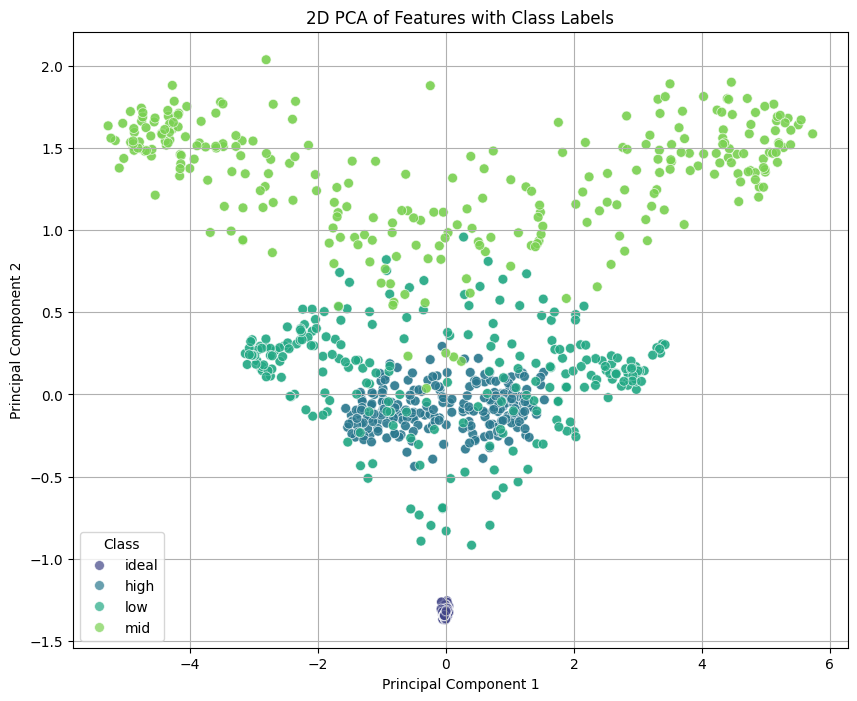

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Apply PCA to reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data = X_pca, columns = ['principal_component_1', 'principal_component_2'])
pca_df['class'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='class',
    data=pca_df,
    palette='viridis',
    s=50,
    alpha=0.7
)
plt.title('2D PCA of Features with Class Labels')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class')
plt.grid(True)
plt.show()

### AUC ROC Curve for Random Forest (One-vs-Rest)

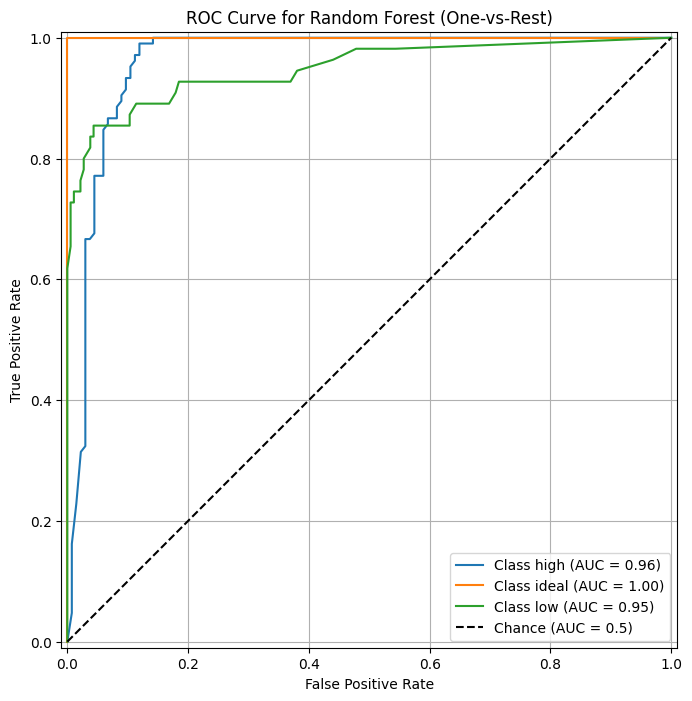

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer

# Encode target labels to binary format for multi-class ROC
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
n_classes = y_test_binarized.shape[1]

# Get prediction probabilities for Random Forest
y_score_rf = rf_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_rf[:, i])
    roc_auc = auc(fpr, tpr)
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=f'Class {label_binarizer.classes_[i]}').plot(ax=plt.gca())

plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5)') # Add diagonal for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()